## ДЗ №2. Матричные факторизации

#### В этой домашке вам предстоит реализовать некоторые базовые модели матричной факторизации

#### Дата выдачи: 17.02.25

#### Мягкий дедлайн: 02.03.25 23:59 MSK

#### Жесткий дедлайн: 09.03.25 23:59 MSK

В этом задании мы будем работать с классическим для рекоендательных систем датасетом [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/). Датасет содержит рейтинги оценки для 4000 фильмов от 6000 пользователей. Более подробное описание можете найти на странице с датасетом и в README файле

In [213]:
# !wget https://files.grouplens.org/datasets/movielens/ml-1m.zip
# !unzip ml-1m.zip
# !cat ml-1m/README

import urllib.request
import zipfile
import os
url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
filename = "ml-1m.zip"

print(f"Скачивание {filename}...")
urllib.request.urlretrieve(url, filename)
print("Скачивание завершено.")

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall(".")
    
readme_path = os.path.join("ml-1m", "README")
if os.path.exists(readme_path):
    with open(readme_path, 'r', encoding='utf-8') as file:
        print(file.read())

Скачивание ml-1m.zip...
Скачивание завершено.
SUMMARY

These files contain 1,000,209 anonymous ratings of approximately 3,900 movies 
made by 6,040 MovieLens users who joined MovieLens in 2000.

USAGE LICENSE

Neither the University of Minnesota nor any of the researchers
involved can guarantee the correctness of the data, its suitability
for any particular purpose, or the validity of results based on the
use of the data set.  The data set may be used for any research
purposes under the following conditions:

     * The user may not state or imply any endorsement from the
       University of Minnesota or the GroupLens Research Group.

     * The user must acknowledge the use of the data set in
       publications resulting from the use of the data set
       (see below for citation information).

     * The user may not redistribute the data without separate
       permission.

     * The user may not use this information for any commercial or
       revenue-bearing purposes without f

In [1]:
import pandas as pd
import numpy as np
from typing import Union
from scipy.linalg import svd
from scipy.sparse.linalg import svds
import warnings
warnings.filterwarnings("ignore")
import pickle
import seaborn as sns
import scipy as sp
import scipy.sparse as scs
import matplotlib
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from PIL import Image
from IPython.display import display
from ipywidgets import interact, widgets
from implicit.als import AlternatingLeastSquares as ALS
from scipy.sparse import coo_matrix, csr_matrix

%matplotlib inline

matplotlib.rcParams['figure.figsize'] = (12, 10)
np.set_printoptions(2, suppress=True)
plt.rcParams.update({'font.size': 14})
import torch
print(torch.cuda.is_available())  
print(torch.version.cuda) 

True
11.8


In [229]:
import chardet
with open('ml-1m/movies.dat', 'rb') as f:
    result = chardet.detect(f.read())
    encoding = result['encoding']

movies_df = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python', names=['movie_id', 'title', 'genres'], encoding=encoding)
movies_df.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
df = pd.read_csv("ml-1m/ratings.dat", sep='::', names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df.drop('timestamp', axis=1, inplace=True)
df.head()

,user_id,item_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [4]:
value_counts = df['item_id'].value_counts()
filtered_values = value_counts[value_counts > 20].index
df = df[df['item_id'].isin(filtered_values)].copy()

In [5]:
train_end = '2000-12-01'
df_train = df[df['datetime'] < train_end].copy()
df_test = df[df['datetime'] >= train_end].copy()
df_train.shape, df_test.shape

((787420, 4), (207432, 4))

In [6]:
train_users = df_train['user_id'].unique()
train_items = df_train['item_id'].unique()

df_test = df_test[df_test['user_id'].isin(train_users)]
df_test = df_test[df_test['item_id'].isin(train_items)]
df_test.shape

(106471, 4)

In [11]:
from sklearn.preprocessing import LabelEncoder

user_le = LabelEncoder()
item_le = LabelEncoder()

df_train['user_id'] = user_le.fit_transform(df_train['user_id'])
df_train['item_id'] = item_le.fit_transform(df_train['item_id'])

df_test['user_id'] = user_le.transform(df_test['user_id'])
df_test['item_id'] = item_le.transform(df_test['item_id'])

In [13]:
print(df_train['user_id'].nunique(), df_train['user_id'].min(),  df_train['user_id'].max())
df_train['item_id'].nunique(), df_train['item_id'].min(),  df_train['item_id'].max()

5365 0 5364


(3010, 0, 3009)

In [15]:
print(df_test['user_id'].nunique(), df_test['user_id'].min(), df_test['user_id'].max())
df_test['item_id'].nunique(), df_test['item_id'].min(),  df_test['item_id'].max()

1147 0 5364


(3002, 0, 3009)

##### Задание 1. Напишем функцию, которая превратит датафрейм в матрицу интеракций. В функции df_to_matrix реализуйте функцию, которая принимает датафрейм и возвращает np.array матрицу интеракций. В функции df_to_coo реализуйте функцию, которая принимает датафрейм и возвращает разреженную матрицу интеракций в coo_array формате

In [17]:
def df_to_matrix(df: pd.DataFrame) -> np.ndarray:
    user_ids = df['user_id'].unique()
    item_ids = df['item_id'].unique()
    
    n_users = len(user_ids)
    n_items = len(item_ids)

    matrix = np.zeros((n_users, n_items))

    for _, row in df.iterrows():
        user_id, item_id, rating = row['user_id'], row['item_id'], row['rating']
        matrix[user_id, item_id] = row['rating']

    return matrix

In [35]:
interactions = df_to_matrix(df_train)

In [20]:
from scipy.sparse import coo_array

def df_to_coo(df: pd.DataFrame) -> coo_array:
    user_ids = df['user_id'].unique()
    item_ids = df['item_id'].unique()
    
    n_users = len(user_ids)
    n_items = len(item_ids)

    matrix = np.zeros((n_users, n_items))

    for _, row in df.iterrows():
        user_id, item_id, rating = row['user_id'], row['item_id'], row['rating']
        matrix[user_id, item_id] = rating
        
    return coo_array(matrix, dtype=np.int16) 

In [21]:
coo_interactions = df_to_coo(df_train)

In [22]:
assert (interactions != 0).sum() == df_train.shape[0]
assert interactions[0, 2994] == 3
assert interactions[2369, 1203] == 5
assert interactions[1557, 459] == 3
assert np.allclose(coo_interactions.toarray(), interactions)

##### Задание 2.1. Рассмотрим [SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition). Возьмите готовую реализуцию алгоритма из numpy.linalg или из scipy.linalg и примените алгоритм к матрицам интеракций, полученным в первом задании. Для работы со sparse матрицей обычная реализация svd не подойдет и нужно будет воспользоваться scipy.sparse.linalg.svds. Вам нужно разложить матрицу интеракций на 3 матрицы U, S, V, а затем перемножить их и восстановить изначальную матрицу. При полном разложении исходная матрица должна восстанавливаться максимально хорошо

In [23]:
def make_svd(interactions: Union[np.ndarray, coo_array], n_singular_values: int = -1):
    # функция должна работать и для полной матрицы и для sparse матрицы(вам поможет isinstance).
    # если n_singular_values = -1, то берем все сингулярные числа для полной матрицы
    # и все кроме одного сингулярного числа для coo-матрицы(иначе scipy.sparse.linalg.svds не будет работать)
    U, S, Vt = None, None, None
    if isinstance(interactions, np.ndarray): 
        U, s, Vt = svd(interactions, full_matrices=False)

    elif isinstance(interactions, coo_array):
        m, n = interactions.shape
        if n_singular_values == -1:
            n_singular_values = min(m, n) - 1
        interactions = interactions.astype(float)
        U, s, Vt = svds(interactions, k=n_singular_values)

    if n_singular_values != -1:
        U = U[: , :n_singular_values]
        S = np.zeros((U.shape[0], Vt.shape[1]))
        S[:len(s), :len(s)] = np.diag(s)
        S = S[: n_singular_values, : n_singular_values]
        Vt = Vt[: n_singular_values, :]
    else:
        S = np.diag(s)

    return U, S, Vt

In [404]:
U, S, V = make_svd(interactions)
assert np.allclose(U @ S @ V, interactions)

In [402]:
U1, S1, V1 = make_svd(interactions, 10)
U, S, V = make_svd(coo_interactions, 10)
assert np.allclose(U1 @ S1 @ V1, U @ S @ V)

##### Задание 2.2. Теперь попробуем сделать рекомендации с помощью SVD. Мы научились восстанавливать исходную матрицу с помощью разложения, теперь же мы хотим порекомендовать пользователю айтемы, которые будут для него максимально релевантны(в восстановленной матрице у них будет самый высокий скор). Для каждого пользователя нужно будет найти индексы айтемов, которые имеют максимальный скор. При этом стоит обратить внимание, что мы не хотим рекомендовать пользователю айтемы, с которыми он уже взаимодействовал

In [24]:
def make_svd_recommendations(interractions: Union[np.ndarray, coo_array], n_singular_values: int = -1, top_k: int = 100):
    # Возвращает матрицу вида n_users, top_k, то есть для каждого пользователя возвращаем индексы 
    # top_k самых релевантный айтемов среди тех с которыми он еще не взаимодействовал
    U, S, Vt = make_svd(interactions, n_singular_values)
    preds_matrix = U @ S @ Vt
    
    n_users, n_items = interactions.shape[0], interactions.shape[1]
    recommendations = np.zeros((n_users, top_k))

    for user_id in range(n_users):
        existing_interactions = set(np.where(interactions[user_id] > 0)[0])
        # Сортируем индексы элементов по убыванию предсказанной релевантности
        sorted_indices = np.argsort(-preds_matrix[user_id])
        
        count = 0
        for idx in sorted_indices:
            if idx not in existing_interactions and count < top_k:
                recommendations[user_id, count] = idx
                count += 1
            if count == top_k:
                break

    return recommendations

In [858]:
recs = make_svd_recommendations(interactions, -1, 100)
assert recs.shape == (interactions.shape[0], 100)

##### Задание 2.3. Теперь давайте посмотрим как будет зависеть качетво рекомендаций, от количества сингулярных чисел, которые мы возьмем в SVD разложении. Переберите n_singular_values из списка [1, 10, 50, 200, 1000] и посмотрите как будет изменяться метрика NDCG на тестовом датасете для таких рекомендаций и как будет меняться время вычисления. Для каждого графики зависимости метрики NDCG от n_singular_values и времени работы алгоритма от n_singular_values(Время работы будет меняться только для sparse-матрицы, стоит запускать алгоритм именно для нее)

In [81]:
def ndcg_metric(gt_items, predicted):
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(
        np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)), dtype=np.float64
    )


def evaluate_recommender(df, model_preds, gt_col="test_interactions", topn=100):
    metric_values = []

    for idx, row in df.iterrows():
        gt_items = row[gt_col]
        metric_values.append((ndcg_metric(gt_items, row[model_preds])))

    return np.mean([x for x in metric_values])

In [20]:
test_df_grouped = df_test.groupby('user_id').apply(lambda x: list(x['item_id'])).reset_index(name='test_interactions')
test_df_grouped.head()

,user_id,test_interactions
0,0,"[925, 926, 2992, 927, 936, 3004, 959, 670, 124..."
1,1,"[927, 928, 929, 933, 2278, 496, 2279, 2284, 30..."
2,3,"[925, 2995, 961, 1848, 839, 2780, 2399, 891]"
3,4,"[580, 665, 666, 1203, 510, 2097, 775, 47]"
4,6,"[1520, 2886, 1521, 934, 569, 2278, 935, 936, 4..."


In [149]:
import time
params = {
    'n_singular_values': [1, 10, 50, 200, 1000],
    'ndcg': [],
    'time': []
}


def plot_graphs(interactions: Union[np.ndarray, coo_array], top_k: int = 100):
    for n_singular_values in params['n_singular_values']:
        start = time.time()
        recommendations = make_svd_recommendations(interactions, n_singular_values)
        
        user_ids = test_df_grouped['user_id'].values
        filtered_recommendations = recommendations[user_ids]
        test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

        ndcg_metr = evaluate_recommender(test_df_grouped, model_preds='SVD_recommendations')
        res = time.time() - start
        
        params['ndcg'].append(ndcg_metr)
        params['time'].append(res)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(params['n_singular_values'], params['ndcg'], marker='o')
    ax1.set_title("Метрика NDCG@100")
    ax1.set_xlabel("n_singular_values")
    ax1.set_ylabel("NDCG@100")
    
    ax2.plot(params['n_singular_values'], params['time'], marker='o', color='orange')
    ax2.set_title("Время работы")
    ax2.set_xlabel("n_singular_values")
    ax2.set_ylabel("Время (секунды)")
    
    plt.tight_layout()
    plt.show()


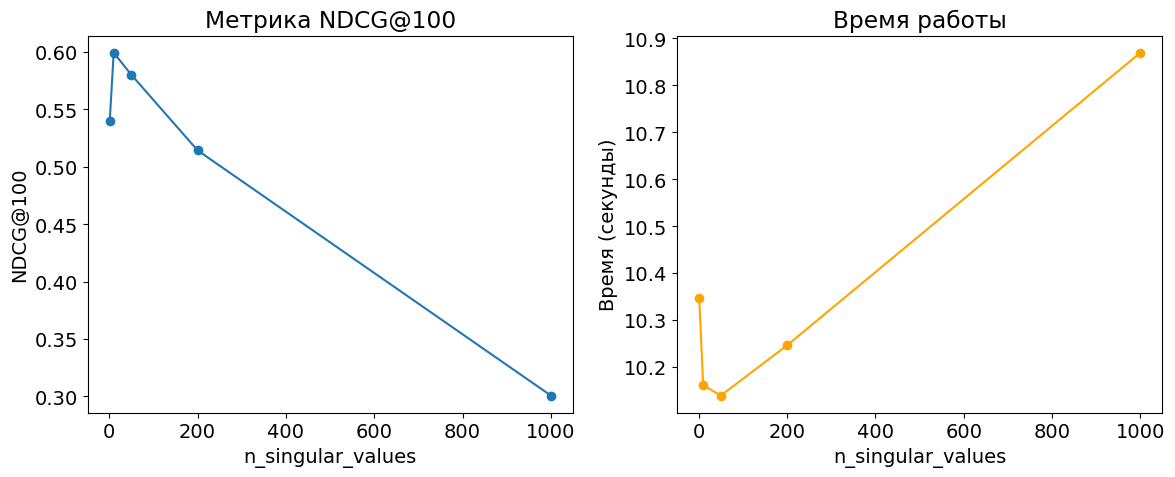

In [153]:
plot_graphs(interactions)

**Выводы**

- SVD показал себя как хороший инструмент для работы с разреженными матрицами взаимодействий пользователей и элементов. Он позволяет уменьшить размерность данных, сохраняя основные закономерности поведения пользователей, что особенно важно при работе с большими наборами данных.
  - 
Основная проблема рекомендательны  систv- — высокая разреженность матриц интеракций. д SVD эффективно справляется с этой задачей, преобразуя исходную матрицу в более компактное представление, где скрытые факторы отражают латентные характеристики пользователей и элементмо
  
- Количество латентных факторов существенно влияет на качество модели. Чем больше сингулярных значений используется, тем точнее наше приближениеим растет и время работы алгоритма
  
- Несмотря на успехи, метод SVD имеет свои ограничения:1.
Необходимость полного хранения матрицы взаимодействий может быть проблемой для очень больших датасетов.2 
Метод плохо работает с холодным стаомm), когда новые пользователи или элементы не имеют достаточной истории взаимодейстйв й3.
Предположение о линейной зависимости между скрытыми факторами может быть слишком упрощённым для некоторых реальных сценар

- На графике мы видим, что чем больше сингулzрных значений мы используем, тем больше времени нужно для обучения модели. Когда количество сингулярных значений увеличивается, модель становится более сложной и имеет больше параметров для обучения. 
Этоприводити к переобучению и вВ результате, качество рекомендаций ухудшается, что отражается в снижении NDC на графике. Оптимальное значение n_singular_values для SVD - 10, где NDCG достигает 0.6, при этом затрачивается наименьшее время для обучения...й.

##### Задание 3.1. Перейдем к [ALS](http://yifanhu.net/PUB/cf.pdf). Возьмем реализацию iALS из библиотеки [implicit](https://benfred.github.io/implicit/api/models/cpu/als.html). Обучите ALS на нашем датасете, сделайте top_k рекомендации для юзеров из тестового датасета, и сравните метрики ALS с метриками, которые получились в SVD. Попробуйте перебрать гиперпараметры и найдите оптимальное число факторов, коэффициент alpha и коэффициент регуляризации.

In [57]:
from implicit.als import AlternatingLeastSquares as ALS
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np

def make_als_recommendations(
    interactions: Union[np.ndarray, coo_matrix], 
    top_k: int = 100, 
    n_factors: int = 100,
    alpha: float = 1.0,
    regularization: float = 0.01,
):
    if not isinstance(interactions, coo_matrix):
        interactions = coo_matrix(interactions)
    
    weighted_interactions = coo_matrix((interactions.data * alpha, (interactions.row, interactions.col)),
                                       shape=interactions.shape)
    
    model = ALS(factors=n_factors, regularization=regularization)
    
    model.fit(weighted_interactions)
    n_users, n_items = interactions.shape
    full_csr = csr_matrix((n_users, n_items), dtype=np.float32)
    full_csr[interactions.row, interactions.col] = interactions.data
    
    recommendations = []
    
    for user_id in range(n_users):
        ids, _ = model.recommend(user_id, full_csr[user_id], N=top_k, filter_already_liked_items=True)
        recommendations.append(ids)
    
    return np.array(recommendations), model

In [190]:
recs, als = make_als_recommendations(interactions)
assert recs.shape == (interactions.shape[0], 100)

  0%|          | 0/15 [00:00<?, ?it/s]

In [185]:
from sklearn.model_selection import ParameterGrid
param_grid = {
    'n_factors': [50, 100, 150],
    'alpha': [1.0, 40.0, 80.0],
    'regularization': [0.01, 0.1, 1.0]
}

best_ndcg = 0
best_params = {}


for params in ParameterGrid(param_grid):
    recommendations = make_als_recommendations(interactions, top_k=100, **params)
    user_ids = test_df_grouped['user_id'].values
    filtered_recommendations = recommendations[user_ids]
    test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations]
    ndcg_score = evaluate_recommender(test_df_grouped, model_preds='ALS_recommendations')

    if ndcg_score > best_ndcg:
        best_ndcg = ndcg_score
        best_params = params

print(f"Лучшие параметры: {best_params}, ndcg@100: {best_ndcg}")

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Лучшие параметры: {'alpha': 1.0, 'n_factors': 50, 'regularization': 0.1}, ndcg@100: 0.5809933868234837


##### Задание 3.2. Сделайте объяснение рекомендаций для нескольких юзеров(als.explain). Воспользуйтесь файлом movies.dat чтобы перейти от индексов фильмов к их названием

In [243]:
row_indices = interactions[:, 0].astype(int)
col_indices = interactions[:, 1].astype(int)
data = interactions[:, 2]
interactions_coo = coo_matrix((data, (row_indices, col_indices)))

recs, model = make_als_recommendations(interactions_coo, top_k=100, **best_params)

  0%|          | 0/15 [00:00<?, ?it/s]

Рекомендации для 0:
  - Heat (1995) (score: 1.0220)
total_score 0.966377909284655


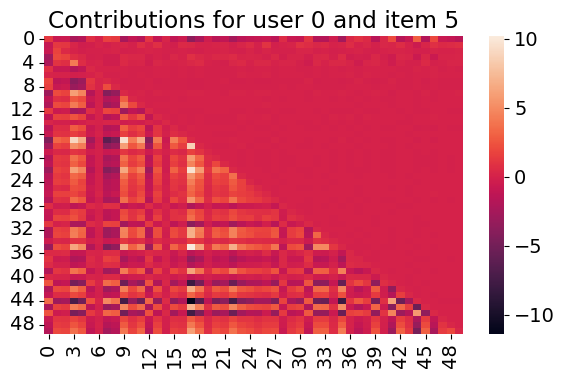

  - Grumpier Old Men (1995) (score: 1.0154)
total_score 1.0088623556111955


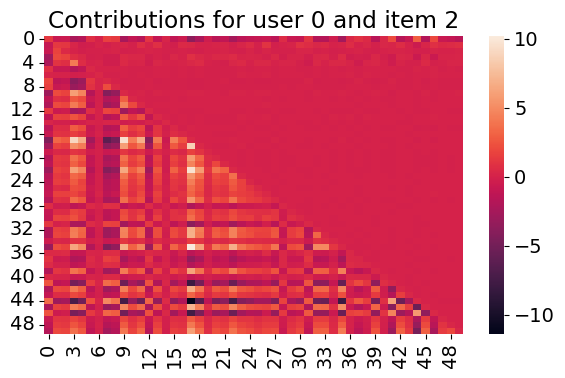

  - Father of the Bride Part II (1995) (score: 1.0019)
total_score 1.0012603688472566


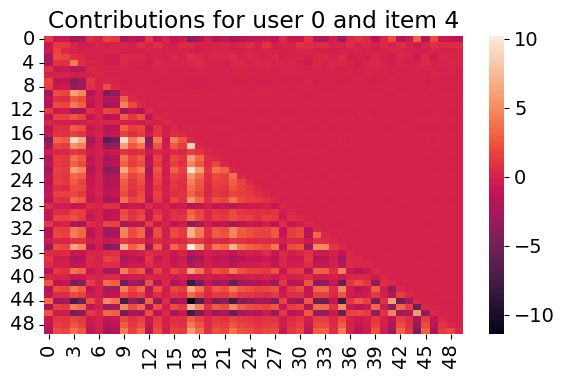

  - Waiting to Exhale (1995) (score: 0.9998)
total_score 0.9985372818797769


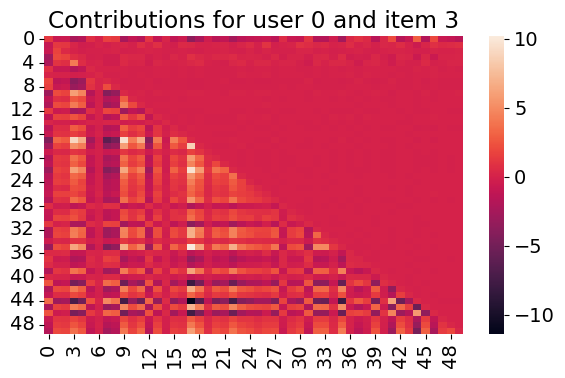

  - Toy Story (1995) (score: 0.9998)
total_score 0.9990712109658728


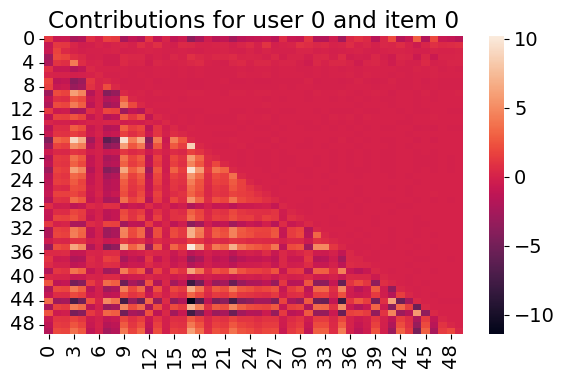

--------------------------------------------------
Рекомендации для 1:
  - Father of the Bride Part II (1995) (score: 0.9014)
total_score 0.9008286094008804


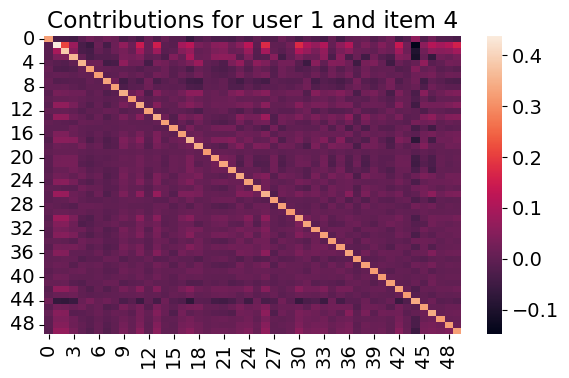

  - Toy Story (1995) (score: 0.2386)
total_score 0.23211901589297196


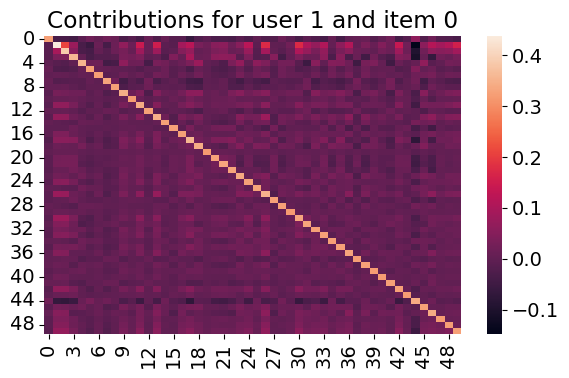

  - Waiting to Exhale (1995) (score: 0.2331)
total_score 0.22670456730684702


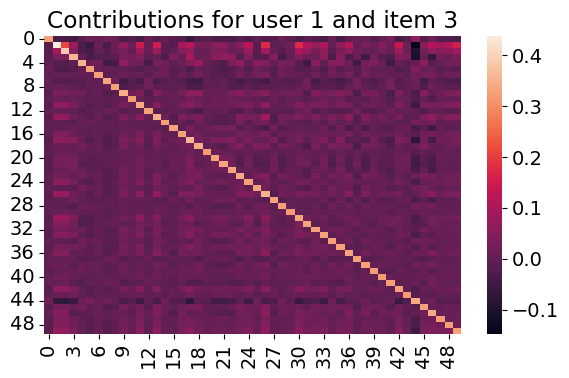

  - Grumpier Old Men (1995) (score: 0.1420)
total_score 0.13853019685164908


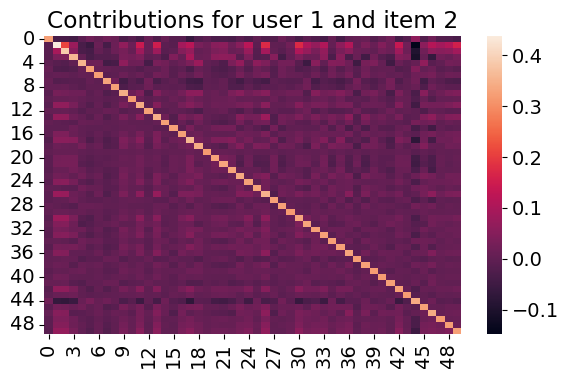

  - Jumanji (1995) (score: 0.0264)
total_score 0.01826739167164218


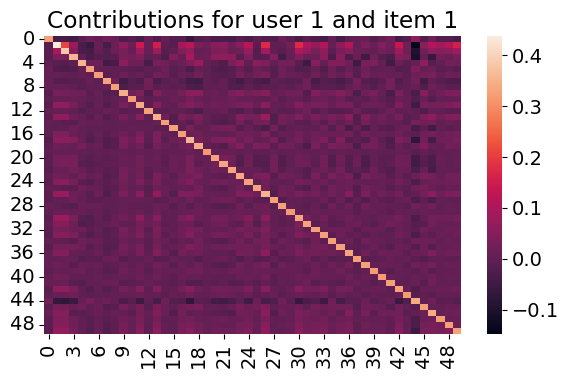

--------------------------------------------------
Рекомендации для 2:
  - Father of the Bride Part II (1995) (score: 1.0406)
total_score 1.0213347335331582


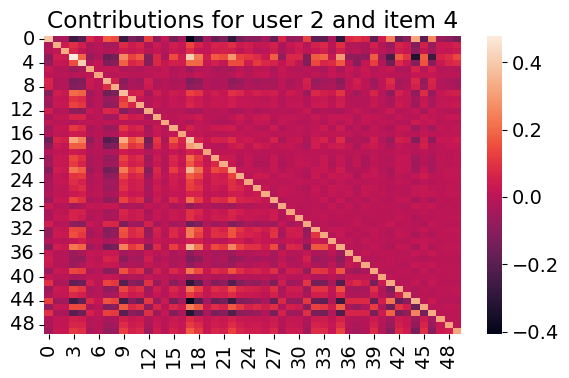

  - Toy Story (1995) (score: 0.9970)
total_score 0.9783381714964741


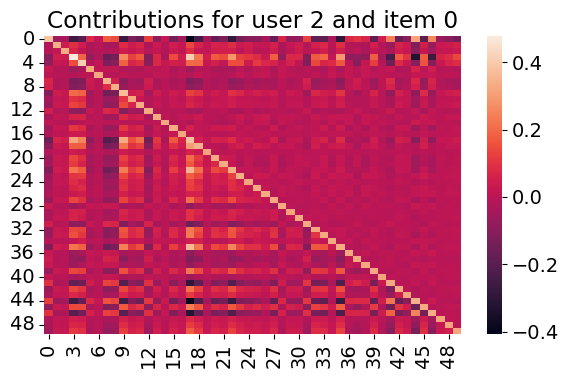

  - Waiting to Exhale (1995) (score: 0.9937)
total_score 0.974986919693184


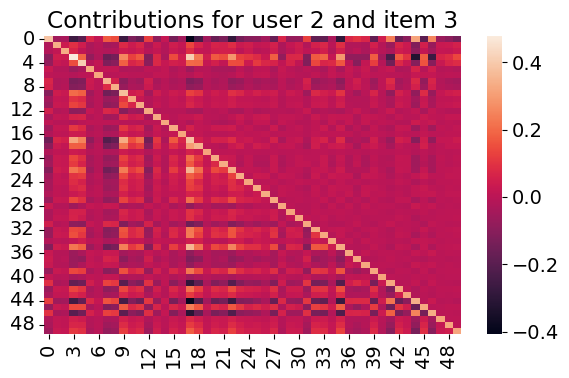

  - Jumanji (1995) (score: 0.9709)
total_score 0.9521458232792728


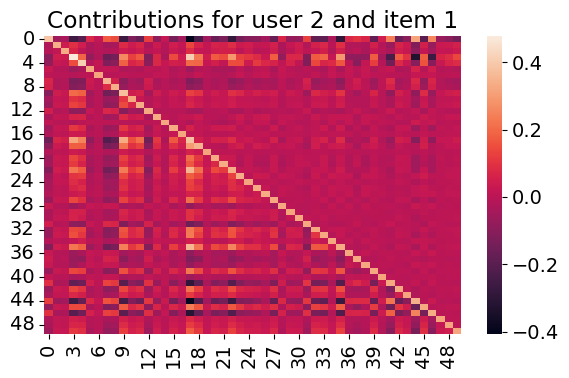

  - Grumpier Old Men (1995) (score: 0.7372)
total_score 0.7119722814748267


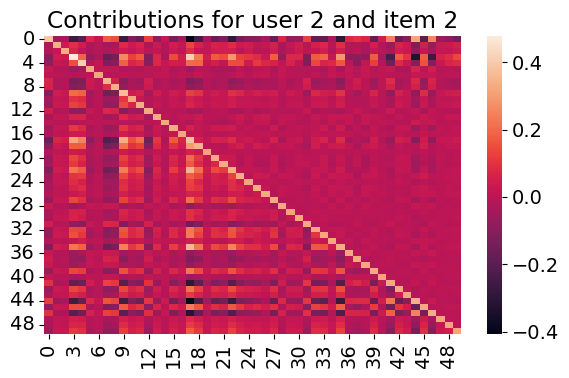

--------------------------------------------------


In [268]:
movie_index_to_title = {row['movie_id'] - 1: row['title'] for idx, row in movies_df.iterrows()}
def explain_recommendations(model, interactions_coo, movie_index_to_title, user_id, top_k=5):
    user_items = interactions_coo.tocsr()
    
    # Получение рекомендаций для пользователя
    item_ids, scores = model.recommend(user_id, user_items[user_id], N=top_k, filter_already_liked_items=False)
    
    print(f"Рекомендации для {user_id}:")
    for item_id, score in zip(item_ids, scores):
        print(f"  - {movie_index_to_title[item_id]} (score: {score:.4f})")
        
        # Объяснение рекомендации
        total_score, _, vectors = model.explain(user_id, user_items, itemid=item_id)
        print('total_score', total_score)
        plt.figure(figsize=(6, 4)) 
        sns.heatmap(vectors[0])
        plt.title(f"Contributions for user {user_id} and item {item_id}")
        plt.tight_layout()
        plt.show()

for user_id in range(3):
    explain_recommendations(model, interactions_coo, movie_index_to_title, user_id)
    print("-" * 50)

- total_score – общий прогнозируеvмая оценка для этой пары пользователь/товар.
- Тепловая карта показывает, какие взаимодействия (например, просмотренные фильмы) вносят наибольший вклад в рекомендацию выбранного фильма для данного пользователя. Яркие клетки на карте указывают на высокие вклады.
- 
Факторы пользователя и элемента (user_factors, item_factors) : Эти векторы представляют пользователя и элемент в латентном пространстве модели ALS. Они используются для вычисления предсказанных рейтингов и рекомендаций 
Таким образом, этот код помогает понять, как модель ALS принимает решение о рекомендации конкретного элемента для пользователя, анализируя вклады взаимодействий и латентные факторы.

##### Задание 4. До этого мы работали с рейтингами, но как обсуждалось на лекции, implicit ALS отлично работает и с implicit фидбэком. Давайте попробуем преобразовать наш датасет(трейн и тест) следующим образом

1. Бинаризуем все рейтинги(заменим любую интеракцию пользователя на 1)
2. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0
3. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1
4. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени. То есть чем дальше была интеракция от максимальной даты трейна, тем с меньшим весом мы будем ее учитывать(например можно интеракции за последний месяц брать в исходном виде, и с каждым месяцем в прошлое умножать их на какой-нибудь коэффициент меньший 1). Таким образом более старые интеракции пользователя будут вносить меньший вклад в его интересы
5. Придумайте свой вариант(опционально)

Для каждой полученной матрицы обучите iALS и SVD и сравните их результаты между собой(преобразовывать нужно только обучающую выборку, тестовую оставляем неизменной)

In [302]:
interactions_bin = np.where(interactions > 0, 1, 0)
interactions_bin_cond = np.where(interactions > 3, 1, 0)
interactions_neg_bin = np.where(interactions > 3, 1, -1)

In [358]:
# 4. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени. То есть чем дальше была интеракция от максимальной даты трейна, тем с меньшим весом мы будем ее учитывать(например можно интеракции за последний месяц брать в исходном виде, и с каждым месяцем в прошлое умножать их на какой-нибудь коэффициент меньший 1). Таким образом более старые интеракции пользователя будут вносить меньший вклад в его интересы
df_train_win = df_train.copy()
df_train_win['datetime'] = pd.to_datetime(df['datetime'])
df_train_win['transformed_rating'] = df_train_win['rating'].apply(lambda x: 1 if x >= 4 else -1)

max_date = df_train_win['datetime'].max()

df_train_win['months_diff'] = (max_date.year - df_train_win['datetime'].dt.year) * 12 + \
                           (max_date.month - df_train_win['datetime'].dt.month)
decay_factor = 0.99
df_train_win['weight'] = decay_factor ** df_train_win['months_diff']

df_train_win['rating'] = df_train_win['transformed_rating'] * df_train_win['weight']
interactions_neg_window_months = df_to_matrix(df_train_win)

In [363]:
# 5. Для последнего варианта возьмем сглаживание по дням
df_train_win = df_train.copy()
df_train_win['datetime'] = pd.to_datetime(df['datetime'])
df_train_win['transformed_rating'] = df_train_win['rating'].apply(lambda x: 1 if x >= 4 else -1)

max_date = df_train_win['datetime'].max()

df_train_win['days_diff'] = (max_date - df_train_win['datetime']).dt.days
decay_factor = 0.99
df_train_win['weight'] = decay_factor ** df_train_win['days_diff']

df_train_win['rating'] = df_train_win['transformed_rating'] * df_train_win['weight']
interactions_neg_window_days = df_to_matrix(df_train_win)

**1. Бинаризуем все рейтинги**

In [398]:
user_ids = test_df_grouped['user_id'].values
svdrecommendations = make_svd_recommendations(interactions_bin, n_singular_values=50)
filtered_recommendations = svdrecommendations[user_ids]
test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

alsrecs, _ = make_als_recommendations(interactions_bin, top_k=100, **best_params)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]

  0%|          | 0/15 [00:00<?, ?it/s]

In [402]:
print(f'SVD NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="SVD_recommendations")}')
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

SVD NDCG@100: 0.5800917068499524
ALS NDCG@100: 0.567840811794696


**2. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0**

In [412]:
user_ids = test_df_grouped['user_id'].values
svdrecommendations = make_svd_recommendations(interactions_bin_cond, n_singular_values=50)
filtered_recommendations = svdrecommendations[user_ids]
test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

alsrecs, _ = make_als_recommendations(interactions_bin_cond, top_k=100, **best_params)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]

  0%|          | 0/15 [00:00<?, ?it/s]

In [414]:
print(f'SVD NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="SVD_recommendations")}')
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

SVD NDCG@100: 0.5800917068499524
ALS NDCG@100: 0.5527358693014346


**3. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1**

In [460]:
user_ids = test_df_grouped['user_id'].values
svdrecommendations = make_svd_recommendations(interactions_neg_bin, n_singular_values=50)
filtered_recommendations = svdrecommendations[user_ids]
test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

alsrecs, _ = make_als_recommendations(interactions_neg_bin, top_k=100)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]

  0%|          | 0/15 [00:00<?, ?it/s]

In [444]:
print(f'SVD NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="SVD_recommendations")}')
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

SVD NDCG@100: 0.5800917068499524
ALS NDCG@100: 0.553693951970749


**4. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по месяцам**

In [461]:
user_ids = test_df_grouped['user_id'].values
svdrecommendations = make_svd_recommendations(interactions_neg_window_months, n_singular_values=50)
filtered_recommendations = svdrecommendations[user_ids]
test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

alsrecs, _ = make_als_recommendations(interactions_neg_window_months, top_k=100, **best_params)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]

  0%|          | 0/15 [00:00<?, ?it/s]

In [462]:
print(f'SVD NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="SVD_recommendations")}')
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

SVD NDCG@100: 0.5800917068499524
ALS NDCG@100: 0.5908202686362984


**5. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по дням**

In [466]:
user_ids = test_df_grouped['user_id'].values
svdrecommendations = make_svd_recommendations(interactions_neg_window_days, n_singular_values=50)
filtered_recommendations = svdrecommendations[user_ids]
test_df_grouped['SVD_recommendations'] = [list(row) for row in filtered_recommendations]

alsrecs, _ = make_als_recommendations(interactions_neg_window_days, top_k=100, **best_params)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]

  0%|          | 0/15 [00:00<?, ?it/s]

In [457]:
print(f'SVD NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="SVD_recommendations")}')
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

SVD NDCG@100: 0.5800917068499524
ALS NDCG@100: 0.549106500007967


- Метод SVD показывает стабильную производительность во всех экспериментах, что указывает на его устойчивость к различным способам бинаризации данных.
  
- Метод ALS более чувствителен к способу кодирования рейтингов

1. 
Наилучший результат достигается при использовании сглаживания по месяцамALS  (NDCG@100: 0.590. Рекомендуется использовать данную комбинацию при дальнейшей работе с рекомендациями с помощью методов матричной факторизаци)и
2.
Наихудший результат наблюдается при сглаживании по дням (NDCG@100: 0.)5
4- )
Простая бинаризация всех рейтин 1) дает лучший или сравнимый результат для ALS по сравнению с более сложными методами кодирния  я.
Использование отрицательных значений (-1 для рейтингов <4) не приводит к значительному улучшению качества рекомендаций для ALS.

##### Задание 5. iALS на numpy/torch. Давайте реализуем алгоритм iALS на нумпае или торче. Требуется реализовать алгорит, описанный в 4 части [статьи](http://yifanhu.net/PUB/cf.pdf). Обратите внимания на все оптимизации, которые они описывают в статье, чтобы сократить лишние вычисления. Hint: метрики у вашего алгоритма должны быть сравнимы с метриками ALS из библиотеки implicit

In [143]:
class iALS:
    def __init__(self, n_factors: int = 100, alpha: float = 1.0, reg_coef: float = 0.01, device='cuda'):
        self.n_factors = n_factors
        self.alpha = alpha
        self.reg_coef = reg_coef
        self.device = device if torch.cuda.is_available() else 'cpu'
        self.interactions = None

    def fit(self, interactions: torch.Tensor, n_iterations: int = 10):
        self.interactions = interactions.to(self.device)
        num_users, num_items = self.interactions.shape
        conf_matrix = self.alpha * self.interactions

        self.user_vecs = torch.randn((num_users, self.n_factors), device=self.device, requires_grad=False)
        self.item_vecs = torch.randn((num_items, self.n_factors), device=self.device, requires_grad=False)

        ident_f = torch.eye(self.n_factors, device=self.device)

        for iter_num in range(n_iterations):
            
            # Векторы пользователей
            item_item_dot = self.item_vecs.T @ self.item_vecs
            for user_idx in range(num_users):
                cu_diag = conf_matrix[user_idx].diag().to(self.device)
                pu = self.interactions[user_idx].to(self.device)
                cu_minus_i = cu_diag - torch.eye(num_items, device=self.device)
                a_mat = item_item_dot + self.item_vecs.T @ cu_minus_i @ self.item_vecs + self.reg_coef * ident_f
                b_vec = self.item_vecs.T @ cu_diag @ pu
                self.user_vecs[user_idx] = torch.linalg.solve(a_mat, b_vec)

            # Векторы айтемов
            user_user_dot = self.user_vecs.T @ self.user_vecs
            for item_idx in range(num_items):
                ci_diag = conf_matrix[:, item_idx].diag().to(self.device)
                pi = self.interactions[:, item_idx].to(self.device)
                ci_minus_i = ci_diag - torch.eye(num_users, device=self.device)
                a_mat = user_user_dot + self.user_vecs.T @ ci_minus_i @ self.user_vecs + self.reg_coef * ident_f
                b_vec = self.user_vecs.T @ ci_diag @ pi
                self.item_vecs[item_idx] = torch.linalg.solve(a_mat, b_vec)

    def predict(self, top_k: int = 100):
        predictions = self.user_vecs @ self.item_vecs.T
        mask = (self.interactions > 0)
        predictions[mask] = -torch.inf
        top_k_indices = torch.argsort(-predictions, dim=1)[:, :top_k]
        return top_k_indices.cpu().numpy()


In [145]:
interactions = torch.tensor(interactions, dtype=torch.float32)
model = iALS(n_factors=10, alpha=1.0, reg_coef=0.01, device='cuda')
model.fit(interactions, n_iterations=10)

In [147]:
user_ids = test_df_grouped['user_id'].values
item_ids  = df['item_id'].unique()
recs_indices = model.predict(top_k=100)
recommendations = np.take(item_ids, recs_indices)

filtered_recommendations = recommendations[user_ids]
test_df_grouped['iALS_recommendations'] = [list(row) for row in filtered_recommendations]
print(f'iALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="iALS_recommendations")}')

iALS NDCG@100: 0.21028439739181906


In [149]:
alsrecs, _ = make_als_recommendations(interactions, top_k=100)
filtered_recommendations_als = alsrecs[user_ids]
test_df_grouped['ALS_recommendations'] = [list(row) for row in filtered_recommendations_als]
print(f'ALS NDCG@100: {evaluate_recommender(test_df_grouped, model_preds="ALS_recommendations")}')

  0%|          | 0/15 [00:00<?, ?it/s]

ALS NDCG@100: 0.5510745385379693
